### Env

In [28]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

### Load Data

In [29]:
df = pd.read_csv("src/tweets_cleaned.csv")
df = df[['processed_text', 'airline_sentiment']].copy()
df = df.reset_index(drop=True)

### Label Encoding

In [30]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['airline_sentiment'])

print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


### Split

In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Training Data:", X_train.shape[0])
print("Testing Data:", X_test.shape[0])
print("Validation Data:", X_val.shape[0])

Training Data: 9870
Testing Data: 2115
Validation Data: 2115


### Vectorize

In [32]:
vectorizer = TfidfVectorizer(max_features=12000)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

### Model

#### Logistic Regression

Logistic Regression Testing Accuracy: 0.8037825059101655


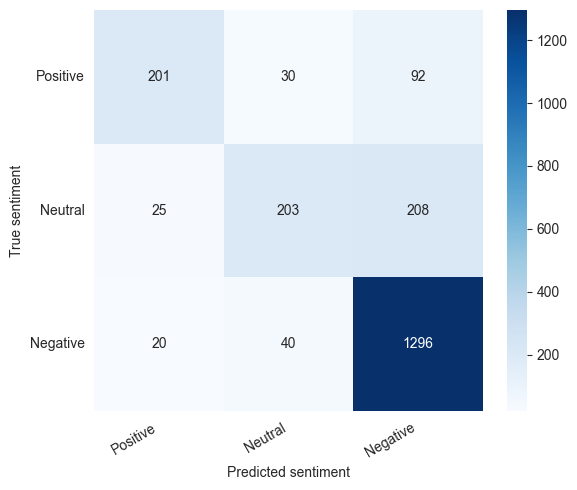


Classification Report:
              precision    recall  f1-score   support

           0     0.8120    0.9558    0.8780      1356
           1     0.7436    0.4656    0.5726       436
           2     0.8171    0.6223    0.7065       323

    accuracy                         0.8038      2115
   macro avg     0.7909    0.6812    0.7191      2115
weighted avg     0.7987    0.8038    0.7889      2115



In [33]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    C=1.0,
    l1_ratio=0,
    solver='lbfgs',
    fit_intercept=True,
)

logreg.fit(X_train_vec, y_train)
y_pred_lr = logreg.predict(X_test_vec)
accuracy_lr = metrics.accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Testing Accuracy:", accuracy_lr)

label_order = [2, 1, 0]
label_map = {
    2: "Positive",
    1: "Neutral",
    0: "Negative"
}

cm = confusion_matrix(y_test, y_pred_lr, labels=label_order)
cm_df = pd.DataFrame(
    cm,
    index=[label_map[i] for i in label_order],
    columns=[label_map[i] for i in label_order]
)

plt.figure(figsize=(6, 5))
hmap = sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
plt.ylabel('True sentiment')
plt.xlabel('Predicted sentiment')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, digits=4))

#### Support Vector Machine

SVM Testing Accuracy: 0.798581560283688


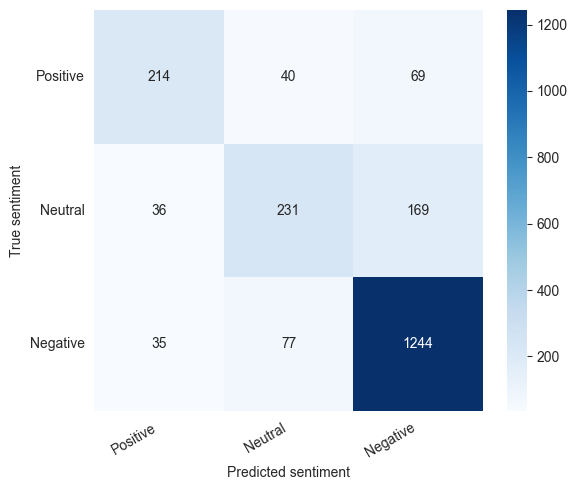


Classification Report:
              precision    recall  f1-score   support

           0     0.8394    0.9174    0.8767      1356
           1     0.6638    0.5298    0.5893       436
           2     0.7509    0.6625    0.7039       323

    accuracy                         0.7986      2115
   macro avg     0.7514    0.7033    0.7233      2115
weighted avg     0.7897    0.7986    0.7911      2115



In [34]:
from sklearn.svm import LinearSVC

svm_linear = LinearSVC(
    C=1.0,
    max_iter=1000,
    dual=False,
    fit_intercept=True
)

svm_linear.fit(X_train_vec, y_train)
y_pred_svm = svm_linear.predict(X_test_vec)
accuracy_svm = metrics.accuracy_score(y_test, y_pred_svm)
print("SVM Testing Accuracy:", accuracy_svm)

label_order = [2, 1, 0]
label_map = {
    2: "Positive",
    1: "Neutral",
    0: "Negative"
}

cm = confusion_matrix(y_test, y_pred_svm, labels=label_order)
cm_df = pd.DataFrame(
    cm,
    index=[label_map[i] for i in label_order],
    columns=[label_map[i] for i in label_order]
)

plt.figure(figsize=(6, 5))
hmap = sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
plt.ylabel('True sentiment')
plt.xlabel('Predicted sentiment')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, digits=4))

#### Random Forest

Random Forest Testing Accuracy: 0.7777777777777778


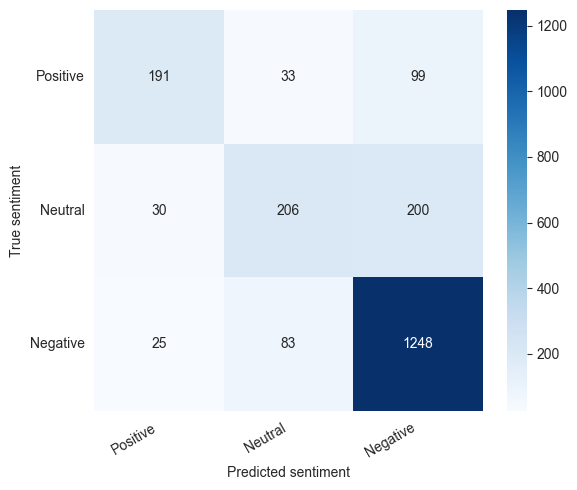


Classification Report:
              precision    recall  f1-score   support

           0     0.8067    0.9204    0.8598      1356
           1     0.6398    0.4725    0.5435       436
           2     0.7764    0.5913    0.6714       323

    accuracy                         0.7778      2115
   macro avg     0.7410    0.6614    0.6916      2115
weighted avg     0.7677    0.7778    0.7658      2115



In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train_vec, y_train)
y_pred_rf = rf.predict(X_test_vec)
accuracy_rf = metrics.accuracy_score(y_test, y_pred_rf)
print("Random Forest Testing Accuracy:", accuracy_rf)

label_order = [2, 1, 0]
label_map = {
    2: "Positive",
    1: "Neutral",
    0: "Negative"
}

cm = confusion_matrix(y_test, y_pred_rf, labels=label_order)
cm_df = pd.DataFrame(
    cm,
    index=[label_map[i] for i in label_order],
    columns=[label_map[i] for i in label_order]
)

plt.figure(figsize=(6, 5))
hmap = sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
plt.ylabel('True sentiment')
plt.xlabel('Predicted sentiment')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))

#### XGBoost

XGBoost Testing Accuracy: 0.7404255319148936


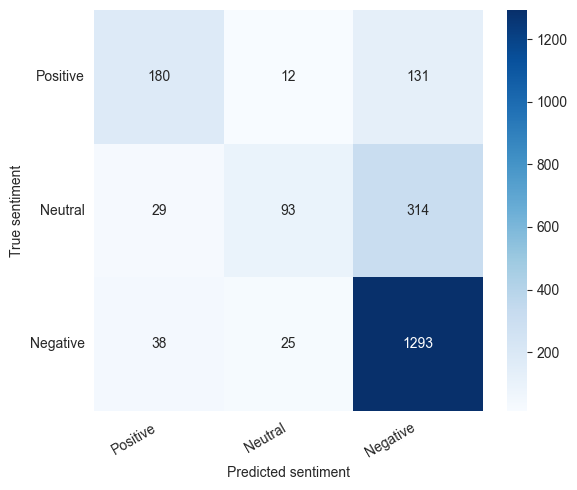


Classification Report:
              precision    recall  f1-score   support

           0     0.7440    0.9535    0.8358      1356
           1     0.7154    0.2133    0.3286       436
           2     0.7287    0.5573    0.6316       323

    accuracy                         0.7404      2115
   macro avg     0.7294    0.5747    0.5987      2115
weighted avg     0.7357    0.7404    0.7001      2115



In [36]:
import xgboost as xgb

xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_vec, y_train)
y_pred_xgb = xgb.predict(X_test_vec)
accuracy_xgb = metrics.accuracy_score(y_test, y_pred_xgb)
print("XGBoost Testing Accuracy:", accuracy_xgb)

label_order = [2, 1, 0]
label_map = {
    2: "Positive",
    1: "Neutral",
    0: "Negative"
}

cm = confusion_matrix(y_test, y_pred_xgb
                      , labels=label_order)
cm_df = pd.DataFrame(
    cm,
    index=[label_map[i] for i in label_order],
    columns=[label_map[i] for i in label_order]
)

plt.figure(figsize=(6, 5))
hmap = sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
plt.ylabel('True sentiment')
plt.xlabel('Predicted sentiment')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, digits=4))